# 0장 실습 — RC 회로에서 LIF 뉴런까지 (바닥부터 구현)

**Spiking Neural Networks 쿡북 with Python** · 0장 실습 노트북

이론에서 유도한 LIF 미분방정식 `τ·du/dt = -(u - u_rest) + R·I(t)`를 **오일러 방법**으로 직접 풀어, snnTorch 없이 순수 파이썬으로 LIF 뉴런을 만든다. 막전위가 충전·누설하다 임계값에서 발화·리셋하는 과정을 눈으로 확인한다.

### 학습 목표
- LIF 미분방정식을 오일러 방법으로 이산화해 한 줄 갱신식으로 만든다.
- 막전위·스파이크를 시각화하고 시정수 τ와 입력 패턴의 효과를 관찰한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다. 발화·리셋은 불리언 산술로 처리한다.

## 1. 라이브러리 임포트

수치 계산에 `numpy`, 시각화에 `matplotlib`을 쓴다. `koreanize-matplotlib`은 그래프 한글이 깨지지 않게 해준다.

In [ ]:
!pip install -q koreanize-matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib   # 그래프 한글 폰트

np.random.seed(0)

## 2. LIF 미분방정식과 오일러 방법

뉴런의 세포막은 RC 회로처럼 거동하며, 막전위 `u(t)`는 다음 미분방정식을 따른다.

$$\tau\,\frac{du}{dt} = -(u(t) - u_{rest}) + R\,I(t)$$

컴퓨터로 풀기 위해 시간을 `dt`로 잘게 쪼개 **오일러 방법**으로 근사한다. 즉 매 스텝마다 막전위 변화량 `du`를 더한다.

$$u_{n+1} = u_n + \frac{\Delta t}{\tau}\big(-(u_n - u_{rest}) + R\,I_n\big)$$

여기에 ‘막전위가 임계값을 넘으면 발화하고 리셋한다’는 규칙만 더하면 LIF 뉴런이 완성된다.

## 3. LIF 뉴런 클래스

`step` 함수는 한 시간 스텝의 동작을 계산한다. 핵심은 **발화·리셋을 조건문 없이** 처리하는 것이다.
- `spike = float(u >= 임계값)` 으로 발화 여부를 `1.0`/`0.0`으로 얻는다(비교식, 조건문 아님).
- `u = u*(1 - spike) + reset*spike` 로, 발화면 리셋값으로 아니면 그대로 둔다(불리언 산술).

전류 단위는 생물학적 범위에 맞춰 피코암페어(pA), 막전위는 mV를 쓴다.

In [2]:
class LIFNeuron:
    def __init__(self, v_rest=-65.0, v_threshold=-55.0, v_reset=-70.0, tau=10.0, g=10.0):
        # 파라미터: 안정 전위·임계 전위·리셋 전위·시정수·컨덕턴스(저항의 역수)
        self.v_rest = v_rest
        self.v_threshold = v_threshold
        self.v_reset = v_reset
        self.tau = tau
        self.g = g
        self.v = v_rest                     # 막전위를 안정 전위로 초기화

    def step(self, current_pa, dt=0.001):
        # (1) 오일러 방법으로 막전위 갱신: 누설 항 + 입력 충전 항
        dv = (-(self.v - self.v_rest) + self.g * current_pa) * dt / self.tau
        self.v = self.v + dv
        # (2) 발화 여부를 0/1로 (if문 없이 비교식)
        spike = float(self.v >= self.v_threshold)
        # (3) 발화면 리셋 전위로, 아니면 그대로 (불리언 산술)
        self.v = self.v * (1.0 - spike) + self.v_reset * spike
        return self.v, spike

neuron = LIFNeuron()
print('초기 막전위:', neuron.v, 'mV')

초기 막전위: -65.0 mV


## 4. 시뮬레이션 실행

100ms 동안 500pA의 일정한 전류를 주입하며, 매 스텝(`dt=0.001s`)마다 막전위와 발화 여부를 기록한다. `for` 루프가 시간의 흐름이다.

In [3]:
observe_ms = 100
dt = 0.001
input_current = 500.0       # pA

neuron = LIFNeuron()
time_axis = np.arange(observe_ms) * dt   # 시간 축 (s)
v_hist = []
spk_hist = []

for ms in range(observe_ms):
    v, spike = neuron.step(current_pa=input_current, dt=dt)
    v_hist.append(v)
    spk_hist.append(spike)

v_hist = np.array(v_hist)
spk_hist = np.array(spk_hist)
print('총 스파이크 수:', int(spk_hist.sum()))

총 스파이크 수: 3


## 5. 막전위 시각화

막전위가 안정 전위(−65mV)에서 충전되어 임계값(−55mV)에 닿으면 발화하고 리셋(−70mV)으로 떨어지는 톱니 모양을 확인한다. 스파이크가 난 시점은 세로선으로 표시한다.

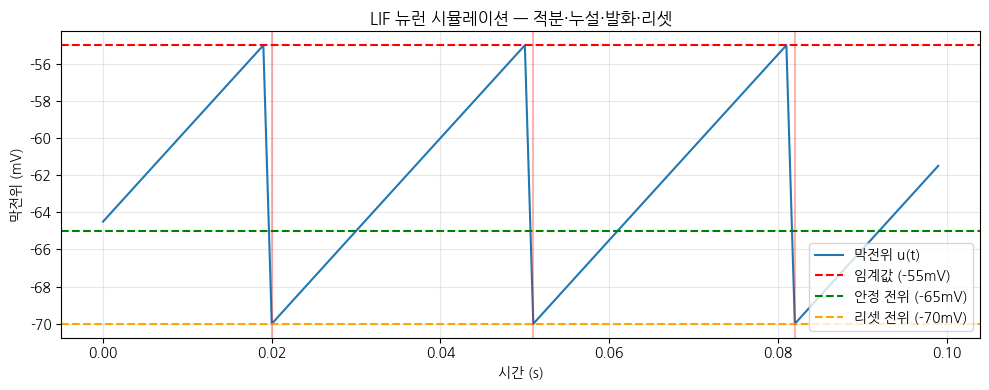

In [4]:
spike_times = time_axis[spk_hist > 0]   # 발화 시점만 추출(불리언 인덱싱)

plt.figure(figsize=(10, 4))
plt.plot(time_axis, v_hist, color='tab:blue', label='막전위 u(t)')
plt.axhline(-55, color='red', linestyle='--', label='임계값 (-55mV)')
plt.axhline(-65, color='green', linestyle='--', label='안정 전위 (-65mV)')
plt.axhline(-70, color='orange', linestyle='--', label='리셋 전위 (-70mV)')
for t in spike_times:
    plt.axvline(t, color='red', alpha=0.3)
plt.xlabel('시간 (s)'); plt.ylabel('막전위 (mV)')
plt.title('LIF 뉴런 시뮬레이션 — 적분·누설·발화·리셋')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. 시정수 τ의 효과

시정수 `τ = RC`는 뉴런의 반응 속도를 정한다. τ가 작으면 빠르게 충전해 자주 발화하고, 크면 천천히 충전해 드물게 발화한다. 세 가지 τ를 같은 입력으로 비교한다.

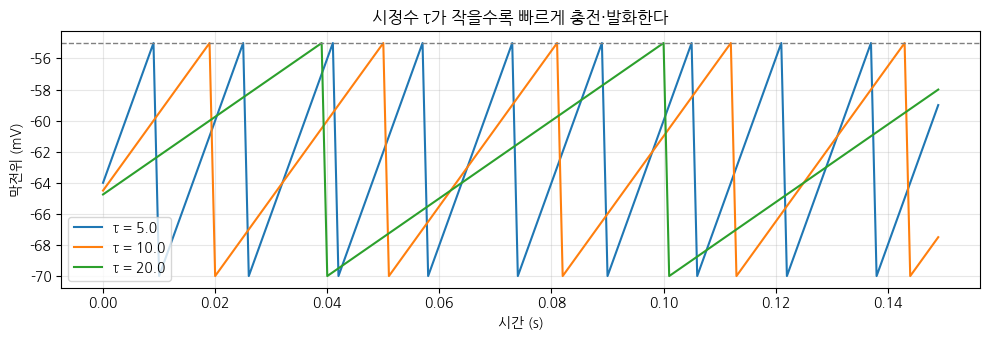

In [5]:
def run(neuron, current_array, dt=0.001):
    v_rec = []
    for I in current_array:
        v, spike = neuron.step(current_pa=float(I), dt=dt)
        v_rec.append(v)
    return np.array(v_rec)

T = 150
const_input = np.full(T, 500.0)
time_axis2 = np.arange(T) * dt

plt.figure(figsize=(10, 3.5))
for tau in [5.0, 10.0, 20.0]:
    v_rec = run(LIFNeuron(tau=tau), const_input)
    plt.plot(time_axis2, v_rec, label=f'τ = {tau}')
plt.axhline(-55, color='gray', linestyle='--', linewidth=1)
plt.xlabel('시간 (s)'); plt.ylabel('막전위 (mV)')
plt.title('시정수 τ가 작을수록 빠르게 충전·발화한다')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. 다양한 입력 패턴

입력 전류를 상수·계단·정현파로 만들어 뉴런의 반응을 비교한다. 패턴은 numpy로 직접 만든다(조건문 불필요).

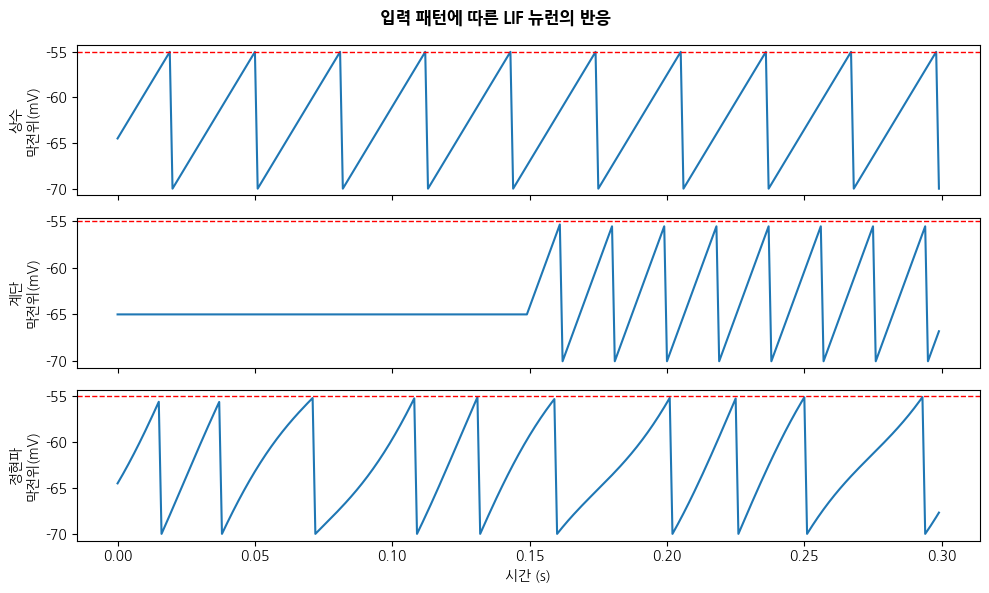

In [6]:
T = 300
t = np.arange(T)

constant = np.full(T, 500.0)                       # 상수 입력
step = np.concatenate([np.zeros(150), np.full(150, 800.0)])   # 계단 입력
sine = 500 + 200 * np.sin(2 * np.pi * t / 100)     # 정현파 입력

patterns = {'상수': constant, '계단': step, '정현파': sine}
time_axis3 = t * dt

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, (name, current) in zip(axs, patterns.items()):
    v_rec = run(LIFNeuron(), current)
    ax.plot(time_axis3, v_rec, color='tab:blue')
    ax.axhline(-55, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel(f'{name}\n막전위(mV)')
axs[-1].set_xlabel('시간 (s)')
fig.suptitle('입력 패턴에 따른 LIF 뉴런의 반응', fontweight='bold')
plt.tight_layout(); plt.show()

## 정리

- LIF 미분방정식을 **오일러 방법**으로 이산화하면 매 스텝 막전위를 한 줄로 갱신할 수 있다.
- 발화·리셋은 `if`문 없이 `spike = float(u >= 임계값)`와 불리언 산술로 구현했다.
- 시정수 τ가 작을수록 빠르게 반응하고, 입력 패턴에 따라 발화 양상이 달라진다.

이 회로·미분방정식 기초 위에서, 1장부터는 SNN의 개념과 전체 흐름을 살펴보고, 4장에서 같은 RC 유도를 snnTorch의 LIF 뉴런(`snn.Lapicque`·`snn.Leaky`)으로 잇는다.